<a href="https://colab.research.google.com/github/Emma-Ok/MonitoriasLogica2/blob/2025-2/Exam_Graphs_and_treesV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

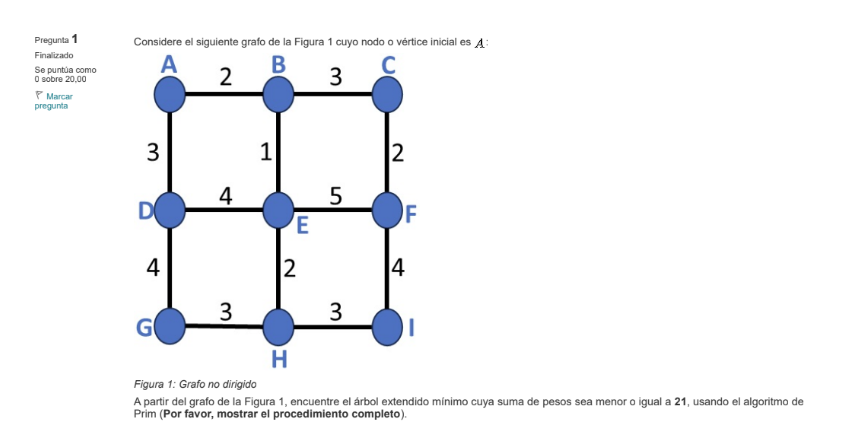

## Recordemos el algoritmo de primm


In [ ]:
def min_peso(pesos, nodo_visitado):
  min_pes = float('inf')
  min_nodo = None
  for nodo in pesos:
    if not nodo_visitado[nodo] and pesos[nodo] < min_pes:
      min_pes = pesos[nodo]
      min_nodo = nodo
  return min_nodo

def prim(W):
  A = []
  v_0 = list(W.keys())[0]
  nodo_visitado = {nodo:False for nodo in W}
  nodo_padre = {nodo:None for nodo in W}
  pesos = {nodo:float('inf') for nodo in W}
  pesos[v_0] = 0
  for _ in range(len(W)):
    u = min_peso(pesos, nodo_visitado)
    nodo_visitado[u] = True
    for v, pes in W[u]:
           if not nodo_visitado[v] and pes < pesos[v]:
              pesos[v] = pes
              nodo_padre[v] = u
  for nodo, nodo_p in nodo_padre.items():
    if nodo_p is not None:
           A.append((nodo_p, nodo, pesos[nodo]))
  return A

In [ ]:
W = {
    'A': [('B', 2), ('D', 3)],
    'B': [('A', 2), ('E', 1), ('C', 3)],
    'C': [('B', 3), ('F', 2)],
    'D': [('A', 3), ('E', 4), ('G', 4)],
    'E': [('B', 1), ('D', 4), ('F', 5), ('H', 2)],
    'F': [('C', 2), ('E', 5), ('I', 4)],
    'G': [('D', 4), ('H', 3)],
    'H': [('G', 3), ('E', 2), ('I', 3)],
    'I': [('F', 4), ('H', 3)],
}


A = prim(W)
peso_total = sum(peso for _, _, peso in A)
print("Arbol extendido:")
if peso_total <= 21:
    for edge in A:
        print(edge)
    print(f"\n✅ Peso total del árbol: {peso_total}")
else:
    print("❌ No se puede construir un árbol extendido con peso menor o igual a 21.")
    print(f"Peso obtenido: {peso_total}")

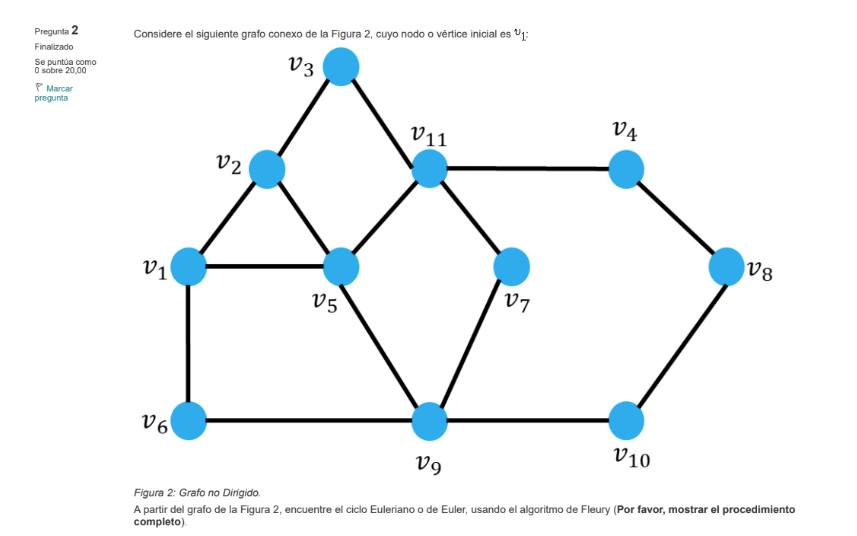

## Recordemos algoritmo de Fleury.

Un ciclo de Euler es un grafo que si incluye cada arista exactamente una única vez. Por lo general, este tipo de trayectoria y ciclo deben cumplir con al menos uno de los siguientes teoremas:​

Teorema 1 del Grafo de Euler​

Un grafo conectado contiene un ciclo de Euler si y solo si cada uno de los vértices tiene un grado de los vértices par.​

Teorema 2 del Grafo de Euler​

Un grafo conectado contiene una trayectoria de Euler si y solo si tiene exactamente dos vértices de grado impar.​

1. Verificar que el grafo es conexo y el grado de todos los vértices sea par. Si no se cumple lo anterior, entonces se detiene el algoritmo y se decide que no es un ciclo de Euler.​

2. Si el paso 1 es verdadero, seleccionar un vértice aleatorio como vértice inicial.​


3. Seleccionar una arista a partir del vértice actual. Es importante que la arista escogida no genere un lado puente, es decir, aquella arista que, en caso de ser eliminada, se pierda la propiedad convexa del grafo.​

4. Desconectar los vértices que están conectados por la arista seleccionada en el paso 3 (Proceso de Eliminación).​

5. Si todos los vértices del grafo ya están desconectados, se obtendrá un ciclo de Euler y finalizar. En caso de que aún no se obtenga el ciclo de Euler, se devuelve al paso 3.

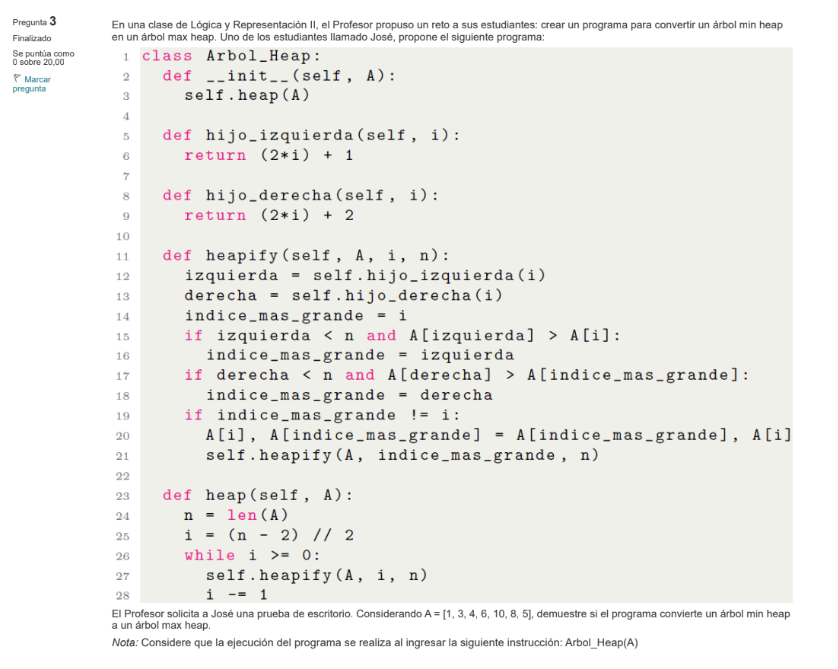


In [ ]:
class Arbol_Heap:
    def __init__(self, A):
        self.heap(A)

    def hijo_izquierdo(self, i):
      return (2*i) + 1

    def hijo_derecho(self, i):
      return (2*i) + 2

    def heapify(self, A, i, n):
      izq = self.hijo_izquierdo(i)
      der = self.hijo_derecho(i)
      indice_mas_grande = i
      if izq < n and A[izq] > A[i]:
        indice_mas_grande = izq
      if der < n and A[der] > A[indice_mas_grande]:
        indice_mas_grande = der
      if indice_mas_grande != i:
        A[i], A[indice_mas_grande] = A[indice_mas_grande], A[i]
        self.heapify(A, indice_mas_grande, n)

    def heap(self, A):
      n = len(A)
      i = (n-2) // 2
      while i >= 0:
        self.heapify(A, i, n)
        i -= 1

**Prueba de escritorio:**

1. **Estado inicial:** [1, 3, 4, 6, 10, 8, 5]
   ```
        1
       / \
      3   4
     / \ / \
    6 10 8  5

<br>
i = 2
```
While i >= 0
  self.heapify(A, 2, 7)
  <br>

    Iteracion 1
    Arbol_heap(A)
      izq = 2*2 + 1 = 5
      der = 2*2 + 2 = 6
      heapify(A,2,7)
     8 (A[5]) > 4 (A[2]) ⇒ indice_mas_grande = 5
     5 (A[6]) > 8 (A[5])? No
     Swap A[2]↔A[5] ⇒ [1,3,8,6,10,4,5]
    ----
    Iteracion 2
    Estado actual ⇒ [1,3,8,6,10,4,5]
      izq = 2*1 + 1 = 3
      der = 2*1 + 2 = 4
      heapify(A,1,7)
      6(A[3]) > 3(A[1])
      indice_mas_grande = 3
      10(A[4]) > 6(A[3])
      indice_mas_grande = 4
      Swap A[1]↔A[4] ⇒ [1,10,8,6,3,4,5]






  <br>



In [ ]:
A = [1, 3, 4, 6, 10, 8, 5]
Arbol_Heap(A)
print(A)


[10, 6, 8, 1, 3, 4, 5]


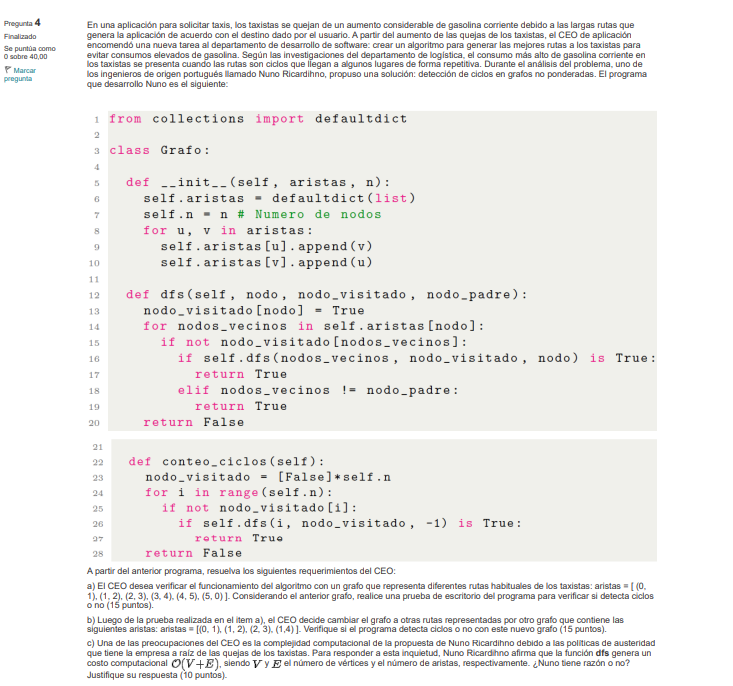

In [ ]:
from collections import defaultdict
class Grafo:

    def __init__(self, aristas, n):
        '''aristas: lista de tuplas (u, v) representando conexiones entre nodos
          n: número total de nodos '''
        self.aristas = defaultdict(list)  # Diccionario que guarda la lista de vecinos para cada nodo
        self.n = n  # Guardamos el número de nodos en el grafo

        # Construimos la lista de adyacencia para un grafo no dirigido
        for u, v in aristas:
            self.aristas[u].append(v)  # Agregamos v como vecino de u
            self.aristas[v].append(u)  # Agregamos u como vecino de v (grafo no dirigido)

    def dfs(self, nodo, nodo_visitado, nodo_padre):
        # Función recursiva para recorrer el grafo usando DFS y detectar ciclos
        nodo_visitado[nodo] = True  # Marcamos el nodo actual como visitado

        for vecino in self.aristas[nodo]:  # Iteramos sobre todos los vecinos del nodo actual
            if not nodo_visitado[vecino]: # Si el vecino aún no ha sido visitado, hacemos DFS recursivamente
                if self.dfs(vecino, nodo_visitado, nodo) is True:
                    return True  # Si en la llamada recursiva se detecta un ciclo, lo propagamos hacia arriba
            elif vecino != nodo_padre:
                # Si el vecino ya fue visitado y NO es el padre del nodo actual, hemos encontrado un ciclo
                return True

        return False  # Si no se encuentra ningún ciclo desde este nodo, devolvemos False

    def conteo_ciclos(self):
        # Esta función recorre todos los nodos y usa DFS para determinar si hay un ciclo
        nodo_visitado = [False] * self.n  # Lista para marcar qué nodos han sido visitados

        for i in range(self.n):  # Recorremos todos los nodos del grafo
            if not nodo_visitado[i]:
                # Si el nodo no ha sido visitado, iniciamos DFS desde él
                if self.dfs(i, nodo_visitado, -1) is True:
                    return True  # Si DFS detecta un ciclo, retornamos True inmediatamente

        return False  # Si ningún componente del grafo contiene ciclos, retornamos False


**Prueba de escritorio:**

0 -> 1 -> 2 -> 3 -> 4 -> 5
|------------------------|

```
Iteracion | nodo actual | nodo padre | vecinos | nodos visitados | función dfs

    1           0             -1         1        [T,F,F,F,F,F]      dfs(1,nv,0)

    2            1             0         0,2      [T,T,F,F,F,F]      dfs(2,nv,1)


  <br>



In [ ]:
aristas = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5,0)]
g1 = Grafo(aristas,6)
print(g1.conteo_ciclos())

True


In [ ]:
aristas = [(0, 1), (1, 2), (2, 3), (1, 4)]
g2 = Grafo(aristas, 5)
print(g2.conteo_ciclos())

False


**Prueba de escritorio:**



```
Iteracion | nodo actual | nodo padre | vecinos | nodos visitados | función dfs

    1           0             -1         1        [T,F,F,F,F]      dfs(1,nv,0)

    2            1             0         0,2      [T,T,F,F,F]      dfs(2,nv,1)
    

  <br>

